In [1]:
import numpy as np
import pandas as pd
from model.Observer import observer
from scipy.integrate import BDF, RK45, RK23, solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt


In [2]:
obs = observer()

In [3]:
# Assumptions
obs.Tfc = 323.15
obs.Pa_des = 1.3e5
obs.Pc_des = 1.0e5
obs.Phi_a_des = 0
obs.Phi_c_des = 1
obs.Sc = 2

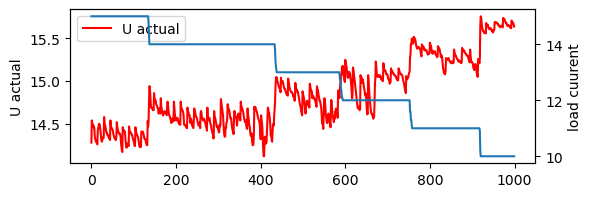

In [4]:
# Experiment data
folder_path = "./data"
no_experiment = 1
data = pd.read_csv(folder_path+"/test0423"+".csv",sep=";")
data["I actual"] = data["I actual"].str.replace("A","",regex=False).str.replace(",",".",regex=False).astype(float)
data["U actual"] = data["U actual"].str.replace("V","",regex=False).str.replace(",",".",regex=False).astype(float)
data = data[["U actual", "I actual"]]
data["I actual"] = data["I actual"].round(1)
u_expdata = data.iloc[8000:9000,0].to_numpy()
i_expdata = data.iloc[8000:9000,1].to_numpy()
fig,ax = plt.subplots(figsize=(6,2))
ax.plot(u_expdata,label="U actual",color="r")
ax.set_ylabel("U actual")
ax_twinx = ax.twinx() 
ax_twinx.plot(i_expdata)
ax_twinx.set_ylabel("load cuurent")
ax.legend()

In [5]:
def iload_rise(t, param):
    cycle_seconds = 3600
    k = 20 / cycle_seconds
    t_cycle = t//cycle_seconds
    return (np.tanh(k*(t - t_cycle*cycle_seconds)) + t_cycle)+10

def iload_const(t, param):
    return 10

Text(0.5, 0, '$t(s)$')

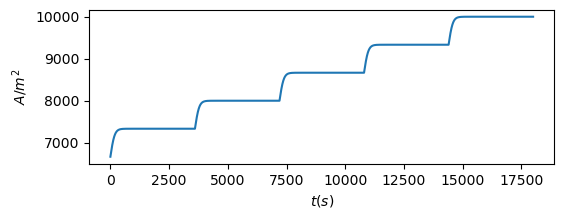

In [6]:
plt.figure(figsize=(6,2))
plt.plot(iload_rise(np.arange(0,3600*5,1),0)/15*1e4)
plt.ylabel(r"$A/m^2$")
plt.xlabel(r"$t(s)$")

In [7]:
# ["lambda_acl","lambda_mem","lambda_ccl", "s_ccl", "C_v_ccl", "s_cgdl", "C_v_cgdl", "C_v_cgc", "C_O2_ccl","C_O2_cgdl","C_O2_cgc","C_N2","Wcp"]
state0 = [4, 4.5, 5, 0.2, 6, 0.1, 5, 4, 4, 6, 8, 25, obs.Wcp_des]

solver = BDF(fun=obs.dxdt, y0=state0,max_step=1, t0=0, t_bound= 4000 + 3600*5)
y_hist = []
ucell_hist = []
iload_hist = []
t = []

while solver.status == "running":
    if solver.t < 4000: 
        obs.i_fc = iload_const(solver.t,0)/15*1e4
    else:
        obs.i_fc = iload_rise(solver.t-4000,0)/15*1e4
    solver.step()
    t.append(solver.t)
    y_hist.append(solver.y)
    iload_hist.append(obs.i_fc)
    ucell_hist.append(obs.Ucell)


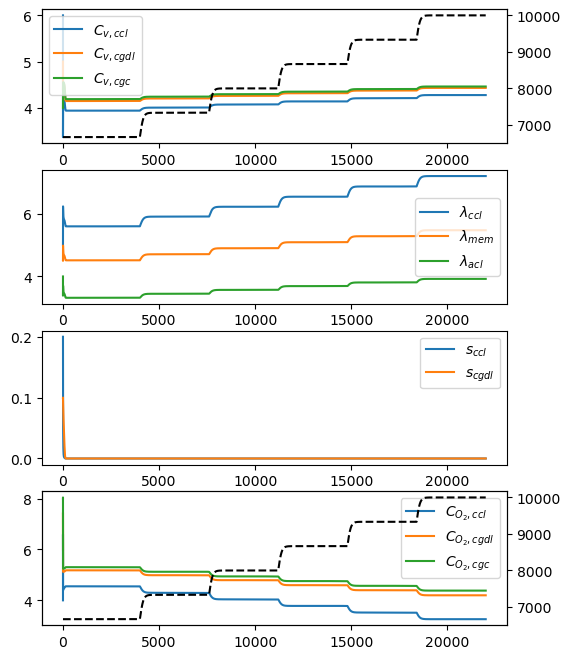

In [8]:
fig, ax = plt.subplots(4,1, figsize = (6,8))
ax[0].plot(t,np.array(y_hist)[:,4], label = r"$C_{v,ccl}$")
ax[0].plot(t,np.array(y_hist)[:,6], label = r"$C_{v,cgdl}$")
ax[0].plot(t,np.array(y_hist)[:,7], label = r"$C_{v,cgc}$")
ax[0].legend()
ax[0].twinx().plot(t, iload_hist,"--",color = '#000000')
ax[1].plot(t,np.array(y_hist)[:,2], label = r"$\lambda_{ccl}$")
ax[1].plot(t,np.array(y_hist)[:,1], label = r"$\lambda_{mem}$")
ax[1].plot(t,np.array(y_hist)[:,0], label = r"$\lambda_{acl}$")
ax[1].legend()
ax[2].plot(t,np.array(y_hist)[:,3], label = r"$s_{ccl}$")
ax[2].plot(t,np.array(y_hist)[:,5], label = r"$s_{cgdl}$")
ax[2].legend()
ax[3].plot(t,np.array(y_hist)[:,-5], label = r"$C_{O_2,ccl}$")
ax[3].plot(t,np.array(y_hist)[:,-4], label = r"$C_{O_2,cgdl}$")
ax[3].plot(t,np.array(y_hist)[:,-3], label = r"$C_{O_2,cgc}$")
ax[3].legend()
ax[3].twinx().plot(t, iload_hist,"--",color = '#000000')

Text(0, 0.5, '$mol/(s\\cdot cm^2)$')

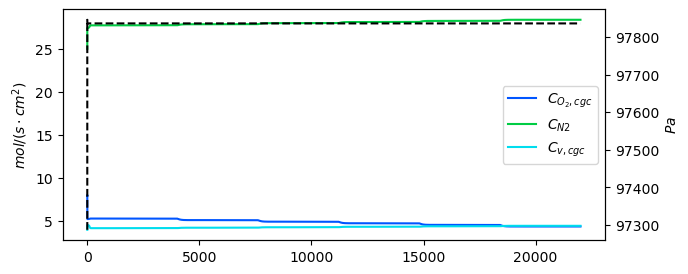

In [9]:
fig, ax = plt.subplots(figsize=(7,3))
colors = ["#0055ff","#00cc44","#00ddee"]
labels = [r"$C_{O_2,cgc}$", r"$C_{N2}$", r"$C_{v,cgc}$"]
i_color = 0
for i_x in [-3, -2, 7]:
    ax.plot(t,np.array(y_hist)[:,i_x],color=colors[i_color],label=labels[i_color])
    i_color += 1
ax_twi = ax.twinx()
ax_twi.plot(t,(np.array(y_hist)[:,-3]+np.array(y_hist)[:,-2]+np.array(y_hist)[:,7])*8.134*323.15, color="black",linestyle="dashed")
ax_twi.set_ylabel(r"$Pa$")
ax.legend(loc="best")
ax.set_ylabel(r"$mol/(s\cdot cm^2)$")
#plt.plot(t[100:],[Psat]*(len(t[100:])))

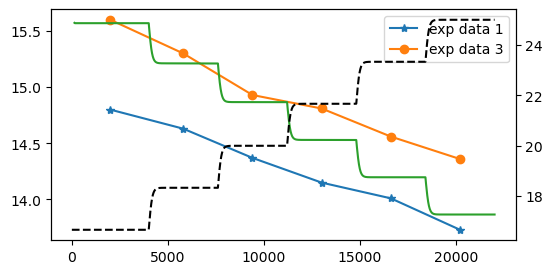

In [10]:
expdata_1 = [14.80, 14.63, 14.37, 14.15, 14.01, 13.73]
expdata_2 = [15.60, 15.30, 14.93, 14.81, 14.56, 14.36]    

fig,ax = plt.subplots(figsize = (6,3))
ax.plot([2000]+[7600+t*3600-1800 for t in range(5)],expdata_1,marker = '*',label = "exp data 1")
ax.plot([2000]+[7600+t*3600-1800 for t in range(5)],expdata_2,marker = 'o',label = "exp data 3")
ax.plot(t[200:],np.array(ucell_hist)[200:]*23)
ax.legend()
ax.twinx().plot(t,np.array(iload_hist)*25e-4,"--",color = '#000000')